### just a grid world with two agent and one goal

In [69]:
import numpy as np
import random
class Agent:
    def __init__(self, size):
        self.size = size
        self.Q = np.zeros((10000000, 5))  # (num_states, num_actions)
        self.epsilon = 0.5
        self.alpha = 0.1
        self.gamma = 0.9
        self.position = [random.randint(0, self.size-1), random.randint(0, self.size-1)]

    def dec_epsilon(self, x):
        if self.epsilon * x >= 0.05:
          self.epsilon = self.epsilon * x

    def choose_action(self, state):
        index = state_to_index(state)
        if np.random.rand() < self.epsilon:
            return np.random.randint(0, 5)
        else:
            return np.argmax(self.Q[index])

    def update(self, state, action, reward, next_state):
        index = state_to_index(state)
        next_index = state_to_index(next_state)
        self.Q[index, action] += self.alpha * (
            reward + self.gamma * np.max(self.Q[next_index]) - self.Q[index, action]
        )
def state_to_index(state):
    x_h1, y_h1, x_h2, y_h2, x_prey, y_prey = state
    pos_h1 = x_h1 + 10*y_h1
    pos_h2 = x_h2 + 10*y_h2
    pos_prey = x_prey + 10*y_prey
    index = pos_prey + pos_h2*100 + pos_h1*10000
    return index

class GridWorld:
    def __init__(self, size, max_steps, agent1, agent2):
        self.size = size
        self.max_steps = max_steps
        self.agent1 = agent1
        self.agent2 = agent2
        self.reset()


    def reset(self):
        self.prey = np.array([random.randint(0, self.size-1), random.randint(0, self.size-1)])
        self.steps = 0
        self.done = False
        return self.get_state()

    def get_state(self): # global positioning
        return (
            int(self.agent1.position[0]), int(self.agent1.position[1]),
            int(self.agent2.position[0]), int(self.agent2.position[1]),
            int(self.prey[0]), int(self.prey[1])
        )


    def move(self, pos, action):
        if action == 0:   # UP
            pos[1] -= 1
        elif action == 1: # RIGHT
            pos[0] += 1
        elif action == 2: # DOWN
            pos[1] += 1
        elif action == 3: # LEFT
            pos[0] -= 1
        elif action == 4: # STAY
            pass

        # torus world
        pos[0] %= self.size
        pos[1] %= self.size
        return pos

    def step(self):
        if self.done:
            return self.get_state(), 0, True

        self.steps += 1
        reward = -1  # negative reward per step

        # random moves
        state = self.get_state()
        agent1_action = None
        agent2_action = None
        for i in range(2):
            if i == 0:
                action = self.agent1.choose_action(state)
                agent1_action = action
                self.agent1.position = self.move(self.agent1.position, action)
            else:
                action = self.agent2.choose_action(state)
                agent2_action = action
                self.agent2.position = self.move(self.agent2.position, action)

        prey_action = random.randint(0, 4)
        self.prey = self.move(self.prey, prey_action)

        # check capture
        if np.array_equal(self.agent1.position, self.prey) or np.array_equal(self.agent2.position, self.prey):
            reward += 100 #همکاری
            self.done = True

        next_state = self.get_state()
        self.agent1.update(state, agent1_action, reward, next_state)
        self.agent2.update(state, agent2_action, reward, next_state)


        if self.steps >= self.max_steps:
            self.done = True

        return self.get_state(), reward, self.done

agent1 = Agent(size=6)
agent2 = Agent(size=6)
for episode in range(50000):
  env = GridWorld(6, 300, agent1, agent2)
  state = env.reset()
  done = False
  while not done:
    state, reward, done = env.step()
  agent1.dec_epsilon(0.99)
  agent2.dec_epsilon(0.99)
print("training finished!")



training finished!


In [70]:
import statistics
steps = []
rewards = []
# agent1.epsilon = 1
# agent2.epsilon = 1
# agent1.epsilon = 0.1
# agent2.epsilon = 0.1
for episode in range(5000):
    step = 0
    env = GridWorld(6, 300, agent1, agent2)
    state = env.reset()
    done = False
    reward_in_game = []
    while not done:
        step += 1
        state, reward, done = env.step()
        reward_in_game.append(reward)
    rewards.append(sum(reward_in_game))
    steps.append(step)
steps_avg = statistics.mean(steps)
rewards_avg = statistics.mean(rewards)
print(agent1.epsilon, agent2.epsilon)
print("average steps: ",steps_avg)
print("average rewards: ",rewards_avg)
print("training finished!")

0.050052937130744816 0.050052937130744816
average steps:  9.0758
average rewards:  90.9242
training finished!


In [71]:
frames = []
rewards = []
done = False
env = GridWorld(6, 300, agent1, agent2)
print("first epsilon: ", agent1.epsilon, "second epsilon: ", agent2.epsilon)
while not done:
    state, reward, done = env.step()
    frames.append(
        (
            np.array([env.agent1.position.copy(), env.agent2.position.copy()]),
            env.prey.copy()
        )
    )
    rewards.append(reward)

first epsilon:  0.050052937130744816 second epsilon:  0.050052937130744816


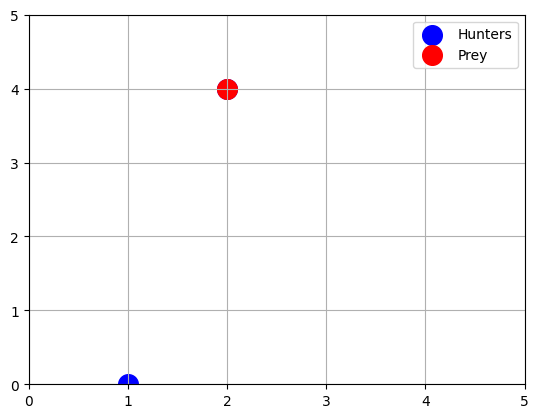

In [72]:
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML
import numpy as np

fig, ax = plt.subplots()
ax.set_xlim(0, 5)
ax.set_ylim(0, 5)
ax.set_xticks(range(6))
ax.set_yticks(range(6))
ax.grid(True)

hunter_scatter = ax.scatter([], [], c='blue', s=200, label='Hunters')
prey_scatter = ax.scatter([], [], c='red', s=200, label='Prey')
ax.legend(loc='upper right')

def init():
    hunter_scatter.set_offsets(np.empty((0, 2)))
    prey_scatter.set_offsets(np.empty((0, 2)))
    return hunter_scatter, prey_scatter

def update(frame):
    hunters, prey = frame

    hunters = np.array(hunters)   # ← این خط کلیدی است
    prey = np.array(prey)

    hunter_scatter.set_offsets(hunters)
    prey_scatter.set_offsets([prey])

    return hunter_scatter, prey_scatter

anim = animation.FuncAnimation(
    fig,
    update,
    frames=frames,
    init_func=init,
    interval=300,
    blit=True
)

HTML(anim.to_jshtml())


### local state

In [74]:
import numpy as np
import random
from collections import defaultdict

class Agent:
    def __init__(self, size):
        self.size = size
        self.Q = defaultdict(lambda: np.zeros(5))
        self.epsilon = 0.5
        self.alpha = 0.1
        self.gamma = 0.9
        self.position = [random.randint(0, self.size-1), random.randint(0, self.size-1)]

    def dec_epsilon(self, x):
        if self.epsilon * x >= 0.05:
          self.epsilon = self.epsilon * x

    def choose_action(self, state):
        # index = state_to_index(state)
        if np.random.rand() < self.epsilon:
            return np.random.randint(0, 5)
        else:
            return np.argmax(self.Q[state])

    def update(self, state, action, reward, next_state):
        # index = state_to_index(state)
        # next_index = state_to_index(next_state)
        self.Q[state][action] += self.alpha * (
            reward + self.gamma * np.max(self.Q[next_state]) - self.Q[state][action]
        )

class GridWorld:
    def __init__(self, size, max_steps, agent1, agent2):
        self.size = size
        self.max_steps = max_steps
        self.agent1 = agent1
        self.agent2 = agent2
        self.reset()


    def reset(self):
        self.prey = np.array([random.randint(0, self.size-1), random.randint(0, self.size-1)])
        self.steps = 0
        self.done = False
        return None

    def get_local_state(self, agent1, agent2):
        dx = agent1.position[0] - self.prey[0]
        dy = agent1.position[1] - self.prey[1]
        if(dx == 0):
            x_direction = 0
        else:
            x_direction = dx / abs(dx)
        if(dy == 0):
            y_direction = 0
        else:
            y_direction = dy / abs(dy) 

        if(abs(dx) < 2):
            dx = 0
        elif(abs(dx) < 4):
            dx = 1 * x_direction
        else:
            dx = 2 * x_direction

        if(abs(dy) < 2):
            dy = 0
        elif(abs(dy) < 4):
            dy = 1 * y_direction
        else:
            dy = 2 * y_direction
        
        agents_x_diff = agent1.position[0] - agent2.position[0]
        agents_y_diff = agent1.position[1] - agent2.position[1]
        same_row = int(agents_x_diff == 0)
        same_col = int(agents_y_diff == 0)
        direction = None
        if(abs(agents_x_diff) > abs(agents_y_diff)):
            if agents_x_diff > 0:
                direction = 1
            else:
                direction = 3
        else:
            if agents_y_diff > 0:
                direction = 0
            else:
                direction = 2

        return(dx, dy, same_row, same_col, direction)
    def get_state(self, agent_num): 
        if(agent_num == 0):
            return self.get_local_state(self.agent1, self.agent2)
        else:
            return self.get_local_state(self.agent2, self.agent1)

    def move(self, pos, action):
        if action == 0:   # UP
            pos[1] -= 1
        elif action == 1: # RIGHT
            pos[0] += 1
        elif action == 2: # DOWN
            pos[1] += 1
        elif action == 3: # LEFT
            pos[0] -= 1
        elif action == 4: # STAY
            pass

        # torus world
        pos[0] %= self.size
        pos[1] %= self.size
        return pos

    def step(self):
        if self.done:
            return  0, True

        self.steps += 1
        reward = -1  # negative reward per step

        # random moves
        state_1 = self.get_state(1)
        state_2 = self.get_state(2)
        agent1_action = None
        agent2_action = None
        for i in range(2):
            if i == 0:
                action = self.agent1.choose_action(state_1)
                agent1_action = action
                self.agent1.position = self.move(self.agent1.position, action)
            else:
                action = self.agent2.choose_action(state_2)
                agent2_action = action
                self.agent2.position = self.move(self.agent2.position, action)

        prey_action = random.randint(0, 4)
        self.prey = self.move(self.prey, prey_action)

        # check capture
        if np.array_equal(self.agent1.position, self.prey) or np.array_equal(self.agent2.position, self.prey):
            reward += 100 #همکاری
            self.done = True

        next_state_1 = self.get_state(0)
        next_state_2 = self.get_state(1)
        self.agent1.update(state_1, agent1_action, reward, next_state_1)
        self.agent2.update(state_2, agent2_action, reward, next_state_2)


        if self.steps >= self.max_steps:
            self.done = True

        return  reward, self.done

agent1 = Agent(6)
agent2 = Agent(6)
for episode in range(50000):
    env = GridWorld(6, 300, agent1, agent2)
    state = env.reset()
    done = False
    while not done:
      reward, done = env.step()
    agent1.dec_epsilon(0.99)
    agent2.dec_epsilon(0.99)
print("training finished!")



training finished!


## test

In [75]:
import statistics
steps = []
rewards = []
# agent1.epsilon = 1
# agent2.epsilon = 1
# agent1.epsilon = 0.1
# agent2.epsilon = 0.1
for episode in range(5000):
    step = 0
    env = GridWorld(6, 300, agent1, agent2)
    state = env.reset()
    done = False
    reward_in_game = []
    while not done:
        step += 1
        reward, done = env.step()
        reward_in_game.append(reward)
    rewards.append(sum(reward_in_game))
    steps.append(step)
steps_avg = statistics.mean(steps)
rewards_avg = statistics.mean(rewards)
print(agent1.epsilon, agent2.epsilon)
print("average steps: ",steps_avg)
print("average rewards: ",rewards_avg)
print("training finished!")

0.050052937130744816 0.050052937130744816
average steps:  11.3206
average rewards:  88.6794
training finished!


## show

In [76]:
frames = []
rewards = []
done = False

env = GridWorld(6, 300, agent1, agent2)
print("first epsilon: ", agent1.epsilon, "second epsilon: ", agent2.epsilon)
counter = 0
while not done:
    counter += 1
    reward, done = env.step()
    frames.append(
        (
            np.array([env.agent1.position.copy(), env.agent2.position.copy()]),
            env.prey.copy()
        )
    )
    rewards.append(reward)
print(counter)
print(rewards)


first epsilon:  0.050052937130744816 second epsilon:  0.050052937130744816
11
[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 99]


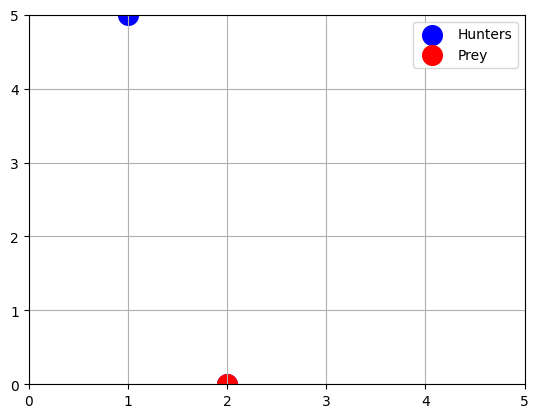

In [77]:
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML
import numpy as np

fig, ax = plt.subplots()
ax.set_xlim(0, 5)
ax.set_ylim(0, 5)
ax.set_xticks(range(6))
ax.set_yticks(range(6))
ax.grid(True)

hunter_scatter = ax.scatter([], [], c='blue', s=200, label='Hunters')
prey_scatter = ax.scatter([], [], c='red', s=200, label='Prey')
ax.legend(loc='upper right')

def init():
    hunter_scatter.set_offsets(np.empty((0, 2)))
    prey_scatter.set_offsets(np.empty((0, 2)))
    return hunter_scatter, prey_scatter

def update(frame):
    hunters, prey = frame

    hunters = np.array(hunters)   # ← این خط کلیدی است
    prey = np.array(prey)

    hunter_scatter.set_offsets(hunters)
    prey_scatter.set_offsets([prey])

    return hunter_scatter, prey_scatter

anim = animation.FuncAnimation(
    fig,
    update,
    frames=frames,
    init_func=init,
    interval=300,
    blit=True
)

HTML(anim.to_jshtml())


## selfish

In [ ]:
import numpy as np
import random
from collections import defaultdict

class Agent:
    def __init__(self, size):
        self.size = size
        self.Q = defaultdict(lambda: np.zeros(5))
        self.epsilon = 0.5
        self.alpha = 0.1
        self.gamma = 0.9
        self.position = [random.randint(0, self.size-1), random.randint(0, self.size-1)]

    def dec_epsilon(self, x):
        if self.epsilon * x >= 0.05:
          self.epsilon = self.epsilon * x

    def choose_action(self, state):
        if np.random.rand() < self.epsilon:
            return np.random.randint(0, 5)
        else:
            return np.argmax(self.Q[state])

    def update(self, state, action, reward, next_state):
        self.Q[state][action] += self.alpha * (
            reward + self.gamma * np.max(self.Q[next_state]) - self.Q[state][action]
        )

class GridWorld:
    def __init__(self, size, max_steps, agent1, agent2, torus):
        self.size = size
        self.max_steps = max_steps
        self.agent1 = agent1
        self.agent2 = agent2
        self.reset()
        self.torus = torus


    def reset(self):
        self.prey = np.array([random.randint(0, self.size-1), random.randint(0, self.size-1)])
        self.steps = 0
        self.done = False
        return None

    def get_local_state(self, agent1, agent2):
        dx = agent1.position[0] - self.prey[0]
        dy = agent1.position[1] - self.prey[1]
        if(dx == 0):
            x_direction = 0
        else:
            x_direction = dx / abs(dx)
        if(dy == 0):
            y_direction = 0
        else:
            y_direction = dy / abs(dy) 

        if(abs(dx) < 2):
            dx = 0
        elif(abs(dx) < 4):
            dx = 1 * x_direction
        else:
            dx = 2 * x_direction

        if(abs(dy) < 2):
            dy = 0
        elif(abs(dy) < 4):
            dy = 1 * y_direction
        else:
            dy = 2 * y_direction
        
        agents_x_diff = agent1.position[0] - agent2.position[0]
        agents_y_diff = agent1.position[1] - agent2.position[1]
        same_row = int(agents_x_diff == 0)
        same_col = int(agents_y_diff == 0)
        direction = None
        if(abs(agents_x_diff) > abs(agents_y_diff)):
            if agents_x_diff > 0:
                direction = 1
            else:
                direction = 3
        else:
            if agents_y_diff > 0:
                direction = 0
            else:
                direction = 2

        return(dx, dy, same_row, same_col, direction)
    def get_state(self, agent_num): 
        if(agent_num == 0):
            return self.get_local_state(self.agent1, self.agent2)
        else:
            return self.get_local_state(self.agent2, self.agent1)

    def move(self, pos, action):
        if action == 0:   # UP
            pos[1] -= 1
        elif action == 1: # RIGHT
            pos[0] += 1
        elif action == 2: # DOWN
            pos[1] += 1
        elif action == 3: # LEFT
            pos[0] -= 1
        elif action == 4: # STAY
            pass

        # torus world
        if (self.torus):
            pos[0] %= self.size
            pos[1] %= self.size
        else:
            if (pos[0] >= self.size):
                pos[0] = self.size -1
            elif(pos[0] < 0):
                pos[0] = 0
            if (pos[1] >= self.size):
                pos[1] = self.size -1
            elif(pos[1] < 0):
                pos[1] = 0
        return pos

    def step(self):
        if self.done:
            return  0, True

        self.steps += 1
        reward = -1  # negative reward per step

        # random moves
        state_1 = self.get_state(1)
        state_2 = self.get_state(2)
        agent1_action = None
        agent2_action = None
        for i in range(2):
            if i == 0:
                action = self.agent1.choose_action(state_1)
                agent1_action = action
                self.agent1.position = self.move(self.agent1.position, action)
            else:
                action = self.agent2.choose_action(state_2)
                agent2_action = action
                self.agent2.position = self.move(self.agent2.position, action)

        prey_action = random.randint(0, 4)
        self.prey = self.move(self.prey, prey_action)

        # check capture
        if np.array_equal(self.agent1.position, self.prey) or np.array_equal(self.agent2.position, self.prey):
            reward += 100 #همکاری
            self.done = True

        next_state_1 = self.get_state(0)
        next_state_2 = self.get_state(1)
        self.agent1.update(state_1, agent1_action, reward, next_state_1)
        self.agent2.update(state_2, agent2_action, reward, next_state_2)


        if self.steps >= self.max_steps:
            self.done = True

        return  reward, self.done

agent1 = Agent(6)
agent2 = Agent(6)
for episode in range(50000):
    env = GridWorld(6, 300, agent1, agent2)
    state = env.reset()
    done = False
    while not done:
      reward, done = env.step()
    agent1.dec_epsilon(0.99)
    agent2.dec_epsilon(0.99)
print("training finished!")



## local and global (modular)

In [4]:
import numpy as np
import random
from collections import defaultdict

class Agent:
    def __init__(self, size):
        self.size = size
        self.Q = defaultdict(lambda: np.zeros(5))
        self.epsilon = 0.5
        self.alpha = 0.1
        self.gamma = 0.9
        self.position = [random.randint(0, self.size-1), random.randint(0, self.size-1)]

    def dec_epsilon(self, x):
        if self.epsilon * x >= 0.05:
          self.epsilon = self.epsilon * x

    def choose_action(self, state):
        # index = state_to_index(state)
        if np.random.rand() < self.epsilon:
            return np.random.randint(0, 5)
        else:
            return np.argmax(self.Q[state])

    def update(self, state, action, reward, next_state):
        # index = state_to_index(state)
        # next_index = state_to_index(next_state)
        self.Q[state][action] += self.alpha * (
            reward + self.gamma * np.max(self.Q[next_state]) - self.Q[state][action]
        )

class GridWorld:
    def __init__(self, size, max_steps, agent1, agent2, is_local):
        self.size = size
        self.max_steps = max_steps
        self.agent1 = agent1
        self.agent2 = agent2
        self.reset()
        self.is_local = is_local


    def reset(self):
        self.prey = np.array([random.randint(0, self.size-1), random.randint(0, self.size-1)])
        self.steps = 0
        self.done = False
        return None

    def get_local_state(self, agent1, agent2):
        dx = agent1.position[0] - self.prey[0]
        dy = agent1.position[1] - self.prey[1]
        if(dx == 0):
            x_direction = 0
        else:
            x_direction = dx / abs(dx)
        if(dy == 0):
            y_direction = 0
        else:
            y_direction = dy / abs(dy) 

        if(abs(dx) < 2):
            dx = 0
        elif(abs(dx) < 4):
            dx = 1 * x_direction
        else:
            dx = 2 * x_direction

        if(abs(dy) < 2):
            dy = 0
        elif(abs(dy) < 4):
            dy = 1 * y_direction
        else:
            dy = 2 * y_direction
        
        agents_x_diff = agent1.position[0] - agent2.position[0]
        agents_y_diff = agent1.position[1] - agent2.position[1]
        same_row = int(agents_x_diff == 0)
        same_col = int(agents_y_diff == 0)
        direction = None
        if(abs(agents_x_diff) > abs(agents_y_diff)):
            if agents_x_diff > 0:
                direction = 1
            else:
                direction = 3
        else:
            if agents_y_diff > 0:
                direction = 0
            else:
                direction = 2

        return(dx, dy, same_row, same_col, direction)
    def get_state(self, agent_num): 
        if (self.is_local):
            if(agent_num == 0):
                return self.get_local_state(self.agent1, self.agent2)
            else:
                return self.get_local_state(self.agent2, self.agent1)
        else:
            return (
            int(self.agent1.position[0]), int(self.agent1.position[1]),
            int(self.agent2.position[0]), int(self.agent2.position[1]),
            int(self.prey[0]), int(self.prey[1])
        )

    def move(self, pos, action):
        if action == 0:   # UP
            pos[1] -= 1
        elif action == 1: # RIGHT
            pos[0] += 1
        elif action == 2: # DOWN
            pos[1] += 1
        elif action == 3: # LEFT
            pos[0] -= 1
        elif action == 4: # STAY
            pass

        # torus world
        pos[0] %= self.size
        pos[1] %= self.size
        return pos

    def step(self):
        if self.done:
            return  0, True

        self.steps += 1
        reward = -1  # negative reward per step

        # random moves
        state_1 = self.get_state(1)
        state_2 = self.get_state(2)
        agent1_action = None
        agent2_action = None
        for i in range(2):
            if i == 0:
                action = self.agent1.choose_action(state_1)
                agent1_action = action
                self.agent1.position = self.move(self.agent1.position, action)
            else:
                action = self.agent2.choose_action(state_2)
                agent2_action = action
                self.agent2.position = self.move(self.agent2.position, action)

        prey_action = random.randint(0, 4)
        self.prey = self.move(self.prey, prey_action)

        # check capture
        if np.array_equal(self.agent1.position, self.prey) or np.array_equal(self.agent2.position, self.prey):
            reward += 100 #همکاری
            self.done = True

        next_state_1 = self.get_state(0)
        next_state_2 = self.get_state(1)
        self.agent1.update(state_1, agent1_action, reward, next_state_1)
        self.agent2.update(state_2, agent2_action, reward, next_state_2)


        if self.steps >= self.max_steps:
            self.done = True

        return  reward, self.done

agent1 = Agent(6)
agent2 = Agent(6)
for episode in range(50000):
    env = GridWorld(6, 300, agent1, agent2, False)
    state = env.reset()
    done = False
    while not done:
      reward, done = env.step()
    agent1.dec_epsilon(0.99)
    agent2.dec_epsilon(0.99)
print("training finished!")



training finished!


## test

In [5]:
import statistics
steps = []
rewards = []
# agent1.epsilon = 1
# agent2.epsilon = 1
# agent1.epsilon = 0.1
# agent2.epsilon = 0.1
for episode in range(5000):
    step = 0
    env = GridWorld(6, 300, agent1, agent2, False)
    state = env.reset()
    done = False
    reward_in_game = []
    while not done:
        step += 1
        reward, done = env.step()
        reward_in_game.append(reward)
    rewards.append(sum(reward_in_game))
    steps.append(step)
steps_avg = statistics.mean(steps)
rewards_avg = statistics.mean(rewards)
print(agent1.epsilon, agent2.epsilon)
print("average steps: ",steps_avg)
print("average rewards: ",rewards_avg)
print("training finished!")

0.050052937130744816 0.050052937130744816
average steps:  8.8032
average rewards:  91.1968
training finished!


## global and local and multi agent (modular)

In [ ]:
import numpy as np
import random
import copy
from collections import defaultdict

def state_to_index(state,is_local,gridSize = 6):#-------------------------------------
    # x1, y1, x2, y2, x3, y3, xp, yp = state
    if is_local == True:
        return state
    pos = 0
    poses = []
    for i in range(len(state)):
        if i % 2 == 0:
            pos += state[i]
        else:
            pos += gridSize * state[i]
            poses.append(pos)
            pos = 0
    # pos_h1 = x1 + 6*y1
    # pos_h2 = x2 + 6*y2
    # pos_h3 = x3 + 6*y3
    # pos_p  = xp + 6*yp
    pow = 0
    index = 0
    base = gridSize * gridSize  #36
    for i in reversed(poses):
        index += i*((base)**pow)
        pow += 1

    return index
class Agent:
    def __init__(self, size, numAgents,numPreys,isLocal,gridSize, greedy_baseline, epsilon):
        self.size = size
        self.isLocal = isLocal
        if isLocal:
            self.Q = defaultdict(lambda: np.zeros(5))
        else:
            NUM_STATES = (gridSize * gridSize) ** (numAgents + numPreys)
            self.Q = np.zeros((NUM_STATES, 5))

        self.epsilon = epsilon
        self.alpha = 0.1
        self.gamma = 0.9
        self.position = [random.randint(0, self.size-1), random.randint(0, self.size-1)]
        self.greedy_baseline = greedy_baseline

    def dec_epsilon(self, x):
        if self.epsilon * x >= 0.05:
          self.epsilon = self.epsilon * x

    def choose_action(self, state):
        index = state_to_index(state,is_local=self.isLocal)#-------------------------------------
        if not self.greedy_baseline:
            if np.random.rand() < self.epsilon:
                return np.random.randint(0, 5)
            else:
                return np.argmax(self.Q[index])
        else:
            dx, dy, _, _, _ = state
            if dx > 0:
                return 3  # LEFT
            elif dx < 0:
                return 1  # RIGHT
            elif dy > 0:
                return 0  # UP
            elif dy < 0:
                return 2  # DOWN
            else:
                return 4  # STAY if already on prey


    def update(self, state, action, reward, next_state):
        index = state_to_index(state,is_local=self.isLocal)#-------------------------------------
        next_index = state_to_index(next_state,is_local=self.isLocal)
        if self.greedy_baseline:
            return
        self.Q[index][action] += self.alpha * (#-------------------------------------
            reward + self.gamma * np.max(self.Q[next_index]) - self.Q[index][action]#-------------------------------------
        )
from enum import Enum

class RewardScenario(Enum):
    COOPERATIVE = "Cooperative"
    SELFISH = "Selfish"

class WallType(Enum):
    TORUS = "Torus"
    HARD = "Hard"
class GridWorld:
    def __init__(self, size, max_steps, agents, is_local, is_random_prey, num_preys, step_reward):
        self.size = size
        self.max_steps = max_steps
        self.num_agents = len(agents)
        self.agents = agents
        self.num_preys = num_preys
        self.reset()
        self.is_local = is_local
        self.rewardSenario = RewardScenario.COOPERATIVE #Selfish
        self.WINNING_REWARD = 100
        self.walls = WallType.TORUS #Hard
        self.is_random_prey = is_random_prey
        self.step_reward = step_reward



    def reset(self):
        self.preys = [
        np.array([random.randint(0, self.size-1),
                random.randint(0, self.size-1)])
                for _ in range(self.num_preys)]
        
        self.steps = 0
        self.done = False
        return None

    def get_local_state(self, agent_idx):
        agent1 = self.agents[agent_idx]
        closest_prey = None
        closest_distance = float('inf')
        for prey in self.preys:
            if self.walls == WallType.TORUS:
                dx = abs(prey[0] - agent1.position[0])
                dy = abs(prey[1] - agent1.position[1])
                dx = min(dx, self.size - dx)
                dy = min(dy, self.size - dy)
                distance = dx + dy
            else:
                distance = abs(prey[0] - agent1.position[0]) + abs(prey[1] - agent1.position[1])
                
            if distance < closest_distance:
                closest_distance = distance
                closest_prey = prey

        if not self.preys:
            dx = 0
            dy = 0
        else:
            if self.walls == WallType.TORUS:
                dx = (agent1.position[0] - closest_prey[0]) % self.size
                if dx > self.size // 2:
                    dx -= self.size
                dy = (agent1.position[1] - closest_prey[1]) % self.size
                if dy > self.size // 2:
                    dy -= self.size
            else:
                dx = agent1.position[0] - closest_prey[0]
                dy = agent1.position[1] - closest_prey[1]

        if(dx == 0):
            x_direction = 0
        else:
            x_direction = dx // abs(dx)
        if(dy == 0):
            y_direction = 0
        else:
            y_direction = dy // abs(dy) 

        if(abs(dx) < 2):
            dx = 0
        elif(abs(dx) < 4):
            dx = 1 * x_direction
        else:
            dx = 2 * x_direction

        if(abs(dy) < 2):
            dy = 0
        elif(abs(dy) < 4):
            dy = 1 * y_direction
        else:
            dy = 2 * y_direction
        
        same_row = 0
        same_col = 0

        # direction histogram: [up, right, down, left]
        agent_dirs = [0, 0, 0, 0]

        for i, other in enumerate(self.agents):
            if i == agent_idx:
                continue

            dx_a = other.position[0] - agent1.position[0]
            dy_a = other.position[1] - agent1.position[1]

            # Same row / column (ANY agent)
            if dx_a == 0:
                same_row = 1
            if dy_a == 0:
                same_col = 1

            # Approximate direction
            if abs(dx_a) > abs(dy_a):
                if dx_a > 0:
                    agent_dirs[1] += 1  # right
                else:
                    agent_dirs[3] += 1  # left
            else:
                if dy_a > 0:
                    agent_dirs[2] += 1  # down
                else:
                    agent_dirs[0] += 1  # up
        
        direction = np.argmax(agent_dirs)

        return(dx, dy, same_row, same_col, direction)
    def get_state(self, agent_idx): 
        if (self.is_local):
            return self.get_local_state(agent_idx)
        else:
            state = []
            for agent in self.agents:
                state.extend(agent.position)
            for prey in self.preys:##
                state.extend(prey)
            return tuple(state)



    def move(self, pos, action):
        x, y = pos
        nx, ny = x, y   # proposed next position

        if action == 0:      # UP
            ny -= 1
        elif action == 1:    # RIGHT
            nx += 1
        elif action == 2:    # DOWN
            ny += 1
        elif action == 3:    # LEFT
            nx -= 1
        elif action == 4:    # STAY
            pass

        if self.walls == WallType.TORUS:
            nx %= self.size
            ny %= self.size
        else:  # Hard walls
            if not (0 <= nx < self.size and 0 <= ny < self.size):
                nx, ny = x, y  # cancel move

        return [nx, ny]
    
    def prey_move(self, prey):
        if (self.is_random_prey):
            return random.randint(0, 4)
        others = [a for i, a in enumerate(self.agents)]
        nearest_agent = None
        if self.walls == WallType.HARD:
            nearest_agent = min(
            others,
            key=lambda a: abs(a.position[0] - prey[0]) +
                        abs(a.position[1] - prey[1])
            ) 
        else: # torus
            nearest_agent = min(
                others,
                key=lambda a: (
                    min(abs(a.position[0] - prey[0]), self.size - abs(a.position[0] - prey[0])) +
                    min(abs(a.position[1] - prey[1]), self.size - abs(a.position[1] - prey[1]))
                )
            )

        
        # print("nearest: ",nearest_agent.position)
        dx = prey[0] - nearest_agent.position[0]
        dy = prey[1] - nearest_agent.position[1]
        if self.walls == WallType.TORUS:
            if abs(dx) > self.size // 2:
                dx -= np.sign(dx) * self.size
            if abs(dy) > self.size // 2:
                dy -= np.sign(dy) * self.size

        if (abs(dx) < abs(dy)):
            if dx > 0:
                return 1
            else:
                return 3
        else:
            if dy > 0:
                return 2
            else:
                return 0

    def step(self):
        if self.done:
            return  0, True
        # print("prey position: ", self.prey)
        self.steps += 1
        reward = self.step_reward  # negative reward per step

        states = []
        actions = []

        for i, agent in enumerate(self.agents):
            state = self.get_state(i)
            action = agent.choose_action(state)
            states.append(state)
            actions.append(action)

        for i in range(len(self.preys)):
            action = self.prey_move(self.preys[i])
            self.preys[i] = self.move(self.preys[i], action)

        for i in range(len(self.agents)):
            self.agents[i].position = self.move(
                self.agents[i].position,
                actions[i]
            )

        winners = set()
        captured_preys = []

        for i, agent in enumerate(self.agents):
            for prey in self.preys:
                if np.array_equal(agent.position, prey):
                    winners.add(i)
                    captured_preys.append(prey)
    
        self.preys = [
            prey for prey in self.preys
            if not any(np.array_equal(prey, cp) for cp in captured_preys)
        ]

        if len(self.preys) == 0:
            self.done = True


        if self.rewardSenario == RewardScenario.COOPERATIVE:
            reward += len(captured_preys) * self.WINNING_REWARD
            for j in range(len(self.agents)):
                next_state = self.get_state(j) 
                self.agents[j].update(states[j], actions[j], reward, next_state)
        elif self.rewardSenario == RewardScenario.SELFISH:
            for j in range(len(self.agents)):
                next_state = self.get_state(j) 
                if j in winners:
                    count = sum(
                        1 for prey in captured_preys
                        if np.array_equal(self.agents[j].position, prey)
                    )                     
                    self.agents[j].update(states[j], actions[j], reward + count * self.WINNING_REWARD, next_state)                    
                else:
                    self.agents[j].update(states[j], actions[j], reward, next_state) 


        if self.steps >= self.max_steps:
            self.done = True

        return  reward, self.done

In [ ]:
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML
import numpy as np
import statistics
import pickle
from collections import defaultdict

def load_qtables(path, agents):
    data = np.load(path, allow_pickle=True)
    meta = data["meta"].item()
    is_local = meta["is_local"]

    for i, agent in enumerate(agents):
        key = f"agent_{i}"
        loaded = data[key]

        # Local mode → dict
        if is_local:
            loaded_dict = loaded.item()
            agent.Q = defaultdict(lambda: np.zeros(5), loaded_dict)

        # Global mode → numpy array
        else:
            agent.Q = loaded

    print("Q-tables loaded")

def print_qtables(agents, max_entries=20):
    for i, agent in enumerate(agents):
        print("\n==============================")
        print(f"Agent {i} Q-table")

        # LOCAL MODE
        if isinstance(agent.Q, dict):
            print(f"Total states stored: {len(agent.Q)}")

            for j, (state, values) in enumerate(agent.Q.items()):
                print(f"{state} -> {values}")
                if j >= max_entries:
                    print("... truncated")
                    break

        # GLOBAL MODE
        else:
            print("Q-table shape:", agent.Q.shape)
            nonzero = np.count_nonzero(agent.Q)
            print("Non-zero entries:", nonzero)

            # print some samples
            indices = np.argwhere(np.sum(agent.Q, axis=1) != 0)
            for idx in indices[:max_entries]:
                print(f"State {idx[0]} -> {agent.Q[idx[0]]}")


def test_game(grid_size, max_steps,num_agents, num_training_episodes, num_test_episodes, is_local, is_random_prey, num_preys, greedy_baseline, decay_value, step_reward, epsilon, is_epsilon_decay, load_existing=False):
    agents = [Agent(grid_size, num_agents, num_preys, is_local, grid_size, greedy_baseline, epsilon) for _ in range(num_agents)]
    qfile = "qtables_local.npz" if is_local else "qtables_global.npz"
    if load_existing:
        load_qtables(qfile, agents)
        for agent in agents:
            agent.epsilon = 0.0   # pure exploitation
    else:
        q_deltas = []#*

        train_rewards = [] ##
        train_steps = [] ##
        for episode in range(num_training_episodes):
            prev_Qs = []#*
            for agent in agents:#*
                prev_Qs.append(copy.deepcopy(agent.Q))#*
            total_reward = 0 ##
            step_count = 0 ##
            env = GridWorld(grid_size, max_steps, agents, is_local, is_random_prey, num_preys, step_reward)
            state = env.reset()
            done = False
            while not done:
                reward, done = env.step()
                total_reward += reward
                step_count += 1
            train_rewards.append(total_reward)
            train_steps.append(step_count)
            if is_epsilon_decay:
                for agent in agents:
                    agent.dec_epsilon(decay_value)
            #############################
            episode_delta = 0.0

            for i, agent in enumerate(agents):
                prev_Q = prev_Qs[i]

                if isinstance(agent.Q, dict):  # local
                    for s in agent.Q:
                        episode_delta += np.linalg.norm(
                            agent.Q[s] - prev_Q.get(s, np.zeros(5))
                        )
                else:  # global
                    episode_delta += np.linalg.norm(agent.Q - prev_Q)

            q_deltas.append(episode_delta)
            ###########################
        print("training finished!")
        # window = 1000
        # threshold = 1e-3

        # converged_episode = None
        # for i in range(window, len(train_rewards)):
        #     prev = np.mean(train_rewards[i-window:i])
        #     curr = np.mean(train_rewards[i-window+1:i+1])
        #     if abs(curr - prev) < threshold:
        #         converged_episode = i
        #         break
        # print("converged episode: ", converged_episode)
        # threshold = 1e-1
        # window = 50

        # converged_episode = None
        # for i in range(window, len(q_deltas)):
        #     if np.mean(q_deltas[i-window:i]) < threshold:
        #         converged_episode = i
        #         break
        # print("2converged episode: ", converged_episode)
        # window = 100          
        # threshold = 1e-3      
        # min_episodes = 200    

        # converged_episode = None

        # for i in range(min_episodes + window, len(q_deltas)):
        #     mean_delta = np.mean(q_deltas[i-window:i])

        #     if mean_delta < threshold:
        #         converged_episode = i
        #         break

        # print("Converged episode (Q-based):", converged_episode)

    print_qtables(agents, max_entries=30)
    steps = []
    #-------------------------------------------------------
    # qtables = {}

    # for i, agent in enumerate(agents):
    #     if isinstance(agent.Q, dict):
    #         qtables[f"agent_{i}"] = dict(agent.Q)   # Local
    #     else:
    #         qtables[f"agent_{i}"] = agent.Q         # Global

    # np.savez("qtables.npz", **qtables)
    # print("qtables.npz saved")

    qtables = {}
    meta = {"is_local": is_local}

    for i, agent in enumerate(agents):
        # qtables[f"agent_{i}"] = agent.Q
        if isinstance(agent.Q, dict):
            qtables[f"agent_{i}"] = dict(agent.Q)  # تبدیل به dict ساده
        else:
            qtables[f"agent_{i}"] = agent.Q

    if not load_existing:
        np.savez(qfile, meta=meta, **qtables)
        print(f"Saved Q-tables to {qfile}")



    #-------------------------------------------------------
    rewards = []
    loose_num = 0
    heatmap = np.zeros((grid_size, grid_size))  # grid size
    for episode in range(num_test_episodes):
        step = 0
        env = GridWorld(grid_size, max_steps, agents, is_local, is_random_prey, num_preys, step_reward)
        state = env.reset()
        done = False
        reward_in_game = []
        while not done:
            step += 1
            reward, done = env.step()
            # heat map
            for agent in env.agents:
                x, y = agent.position
                heatmap[y, x] += 1   # y first for imshow

            reward_in_game.append(reward)
        if reward_in_game[-1] <= 0:
            loose_num += 1
        rewards.append(sum(reward_in_game))
        steps.append(step)
    heatmap = heatmap / np.max(heatmap)
    steps_avg = statistics.mean(steps)
    rewards_avg = statistics.mean(rewards)
    success_rate = (num_test_episodes - loose_num) / num_test_episodes
    # print(agent1.epsilon, agent2.epsilon)
    print("testing finished!")
    print("average steps: ",steps_avg)
    print("average rewards: ",rewards_avg)
    print("success rate: ", success_rate)
    # print heat map:
    plt.figure(figsize=(6, 6))
    plt.imshow(heatmap, cmap="hot", origin="lower")
    plt.colorbar(label="Visit Frequency")
    plt.title("Heatmap of Frequent Hunter Paths")
    plt.xticks(range(6))
    plt.yticks(range(6))
    plt.grid(False)
    plt.show()

    
    frames = []
    rewards = []
    done = False

    env = GridWorld(6, 100, agents, is_local, is_random_prey, num_preys, step_reward)
    print("epsilons:", [agent.epsilon for agent in agents])
    counter = 0
    while not done:
        counter += 1
        reward, done = env.step()
        frames.append(
            (
                # np.array([agent.position.copy() for agent in env.agents]),
                # np.array([prey.copy() for prey in env.preys])
            [agent.position.copy() for agent in env.agents],
            [prey.copy() for prey in env.preys]
            )
        )
        rewards.append(reward)
    print(counter)
    print(rewards)
    fig, ax = plt.subplots()
    ax.set_xlim(0, grid_size - 1)
    ax.set_ylim(0, grid_size - 1)
    ax.set_xticks(range(grid_size))
    ax.set_yticks(range(grid_size))
    ax.grid(True)

    hunter_scatter = ax.scatter([], [], c='blue', s=200, label='Hunters')
    prey_scatter = ax.scatter([], [], c='red', s=200, label='Preys')

    def init():
        hunter_scatter.set_offsets(np.empty((0, 2)))
        prey_scatter.set_offsets(np.empty((0, 2)))
        return hunter_scatter, prey_scatter

    def update(frame):
        hunters, preys = frame

        hunters = np.asarray(hunters).reshape(-1, 2)

        preys = np.asarray(preys)
        if preys.size == 0:
            preys = np.empty((0, 2))
        else:
            preys = preys.reshape(-1, 2)

        hunter_scatter.set_offsets(hunters)
        prey_scatter.set_offsets(preys)

        return hunter_scatter, prey_scatter

    anim = animation.FuncAnimation(
        fig,
        update,
        frames=frames,
        init_func=init,
        interval=300,
        blit=True
    )

    return HTML(anim.to_jshtml())


# tests

### Agent random move:

training finished!
Converged episode (Q-based): None

Agent 0 Q-table
Total states stored: 214
(1, 0, 0, 0, 2) -> [ 77.42692551  53.31113647  81.39390864 148.72226786  91.3852141 ]
(0, 0, 0, 0, 3) -> [123.39096419 117.74690206 117.59129807 113.46199498 109.29497431]
(-1, 0, 0, 0, 3) -> [ 16.98619048 125.64376476  11.529544    31.71930562  15.37443601]
(-1, 1, 0, 0, 0) -> [130.2711543  106.64239049  71.47047007  73.18779592  99.19236245]
(-1, 0, 0, 0, 0) -> [118.36725527 131.22376139 124.28919451 116.5663427  127.2360054 ]
(-1, 0, 0, 1, 3) -> [ 3.37873293e+01  1.31192381e+02 -5.88109923e-03  1.59885256e+01
  4.05233268e+01]
(-1, 0, 1, 1, 0) -> [ 40.74477311  67.21653013 114.99329289  42.542894    25.95615379]
(-1, 0, 0, 1, 1) -> [ 98.45199753 135.42417461 127.64852081 102.40592199  95.92177188]
(-1, 0, 1, 0, 0) -> [ 65.04582977 147.00700149  59.9159373   93.34440904  84.50815801]
(-1, 1, 0, 0, 1) -> [ 46.24733044 135.8776545   21.50093585  28.73567637  44.94152099]
(0, 0, 0, 0, 0) -> [1

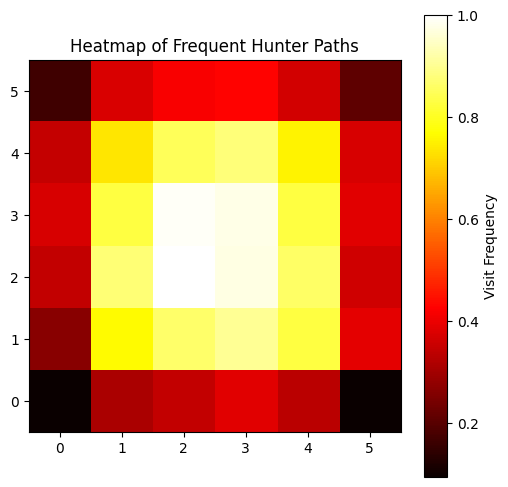

epsilons: [0.05003682746732073, 0.05003682746732073]
9
[-1, -1, -1, -1, -1, -1, -1, -1, 99]


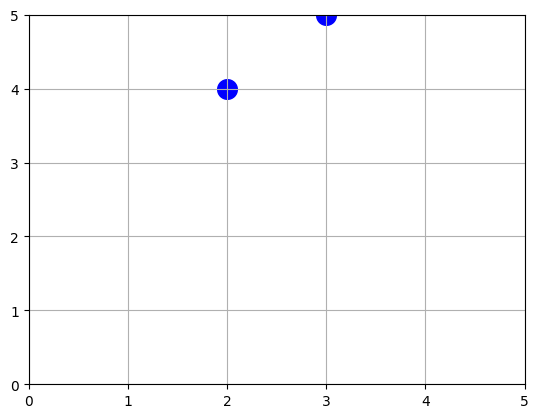

In [41]:
test_game(6, 100, 2, 10000, 5000, True, True, 1, False, 0.998, -1, 1, True, load_existing=False)

### Agent greedy move:

training finished!
Converged episode (Q-based): 300

Agent 0 Q-table
Total states stored: 0

Agent 1 Q-table
Total states stored: 0
Saved Q-tables to qtables_local.npz
testing finished!
average steps:  12.3944
average rewards:  187.6056
success rate:  1.0


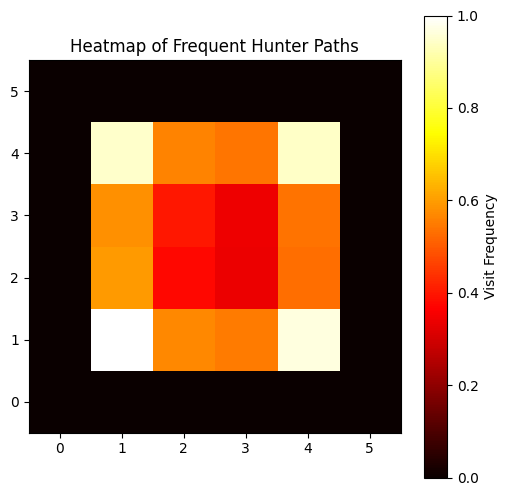

epsilons: [0.05003682746732073, 0.05003682746732073]
13
[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 199]


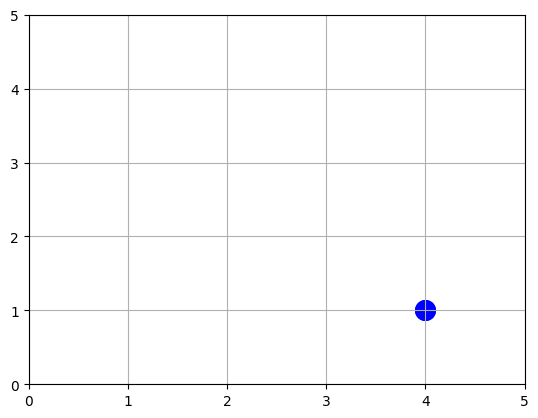

In [40]:
test_game(6, 100, 2, 10000, 5000, True, True, 1, True, 0.998, -1, 1, True, load_existing=False)

### reward = -2

training finished!
Converged episode (Q-based): None

Agent 0 Q-table
Total states stored: 211
(0, 1, 0, 0, 2) -> [99.52400307 63.35636872 41.20088572 60.96644437 72.87613603]
(0, 0, 0, 0, 2) -> [101.26807233 102.16506332 114.38180318  99.12468666 104.30719103]
(1, 1, 0, 0, 3) -> [ 1.32397555  6.72266106 75.41556607 -0.38       11.81910806]
(1, 1, 0, 0, 2) -> [95.42693083 12.26429031  6.04845176 16.81887422  2.7894337 ]
(1, 1, 0, 1, 3) -> [87.05643368 -0.38       24.72276318 11.43442409  3.50648915]
(0, 1, 0, 1, 3) -> [105.68403671  20.59243793   0.51470782   3.19846183   2.15515633]
(0, 1, 0, 0, 3) -> [109.55925699  22.08524622   9.90444206   5.00729849  18.68450989]
(-1, 1, 1, 0, 2) -> [89.04599202  0.          8.97490163  6.52957616  0.        ]
(-1, 1, 0, 0, 2) -> [91.05207602 15.68298932  0.         29.14950771 16.1880069 ]
(-2, 1, 0, 0, 2) -> [ 2.80738065 68.96366274  0.15173647  5.80547546  5.03892236]
(-2, 1, 1, 0, 2) -> [-0.2       49.1493334 -0.38       0.        -0.542    ]


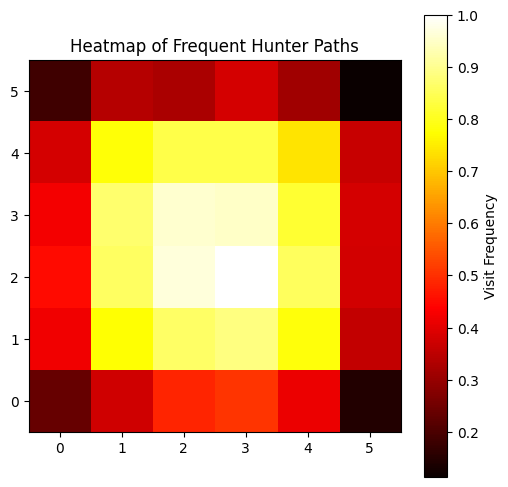

epsilons: [0.05003662286632564, 0.05003662286632564]
13
[-2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, 98]


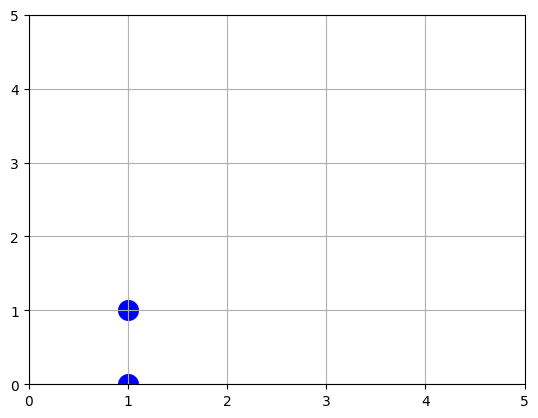

In [43]:
test_game(6, 100, 2, 10000, 5000, True, True, 1, False, 0.99, -2, 1, True ,load_existing=False)

### reward = -1

In [ ]:
test_game(6, 100, 2, 5000, 5000, True, True, 1, False, 0.99, -1, 1, True ,load_existing=False)

TypeError: test_game() missing 2 required positional arguments: 'epsilon' and 'is_epsilon_decay'

### hard wall greedy escape

training finished!
Converged episode (Q-based): None

Agent 0 Q-table
Total states stored: 215
(0, -1, 0, 0, 1) -> [23.29445293  2.91691452 45.88301344 10.8401602   7.48538499]
(-1, -2, 0, 1, 1) -> [ 2.2149926  -0.377929   38.59945224  1.41358021  0.72012694]
(0, -2, 0, 1, 1) -> [-0.385219   46.66266453  6.36923922 -0.36181    -0.385219  ]
(1, -2, 0, 0, 2) -> [ 8.96639201  1.26138875 52.46988428 -0.11479396 -0.07426918]
(1, -2, 0, 1, 1) -> [ 3.95440313 -0.19        6.96300906 -0.215929   34.6124323 ]
(2, -2, 1, 1, 0) -> [-0.25930246 -0.12953477 -0.19        4.89560706 -0.1       ]
(2, -2, 0, 1, 1) -> [-0.07055499 -0.1        -0.1         4.24559351 -0.1       ]
(2, -2, 1, 0, 2) -> [-0.36354411 -0.199      -0.22653893  9.87783109 -0.20791   ]
(2, -2, 0, 0, 2) -> [-0.45486745 -0.63249546 -0.36019    21.38250668 -0.38801753]
(2, -2, 0, 0, 3) -> [ 1.88532224 -0.65478519 56.67089914 -0.25367696 -0.59425719]
(2, -1, 0, 1, 3) -> [ 0.95207745  5.45356968 67.01596876 -0.23087548  5.67857284]
(2

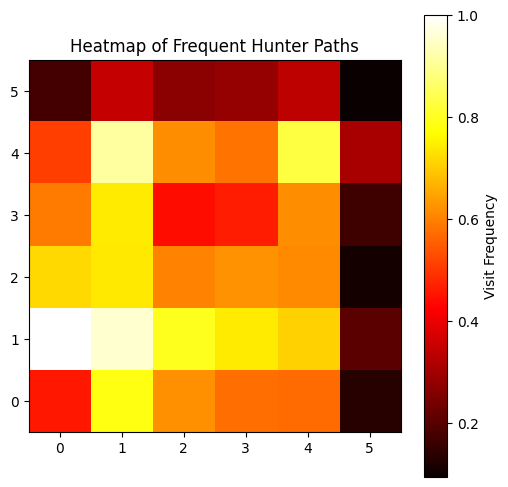

epsilons: [0.05003662286632564, 0.05003662286632564]
12
[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 99]


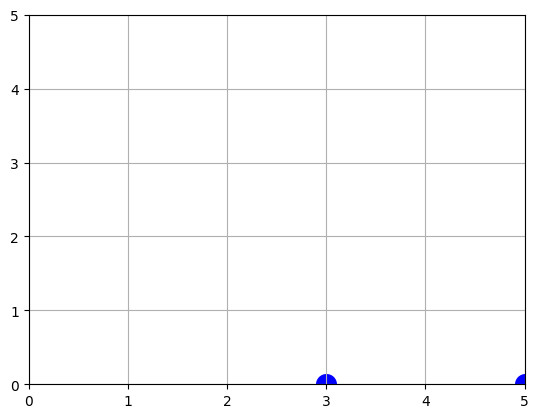

In [49]:
test_game(6, 100, 2, 5000, 5000, True, False, 1, False, 0.99, -1, 1, True ,load_existing=False)

## torus geedy escape

In [ ]:
test_game(6, 100, 2, 5000, 5000, True, False, 1, False, 0.99, -1, 1, True ,load_existing=False)

training finished!

Agent 0 Q-table
Total states stored: 81
(1, 0, 0, 1, 3) -> [ 7.41956625 13.07851762 11.33274356 20.86634593 12.00293907]
(1, 0, 0, 0, 3) -> [14.08236989 14.23336907 11.44334113 28.90005214  4.69119982]
(0, 0, 0, 0, 3) -> [26.91077997 24.21706624 20.03863291 32.37481144 23.89132458]
(0, 1, 0, 0, 3) -> [12.53757769 11.5891277  12.63049338 31.02897992 13.42015808]
(-1, 1, 0, 0, 3) -> [10.9587907   9.8272043  25.62857938 11.37459409 12.80844202]
(0, 1, 0, 0, 0) -> [23.0427472  21.65757701 47.10579632 21.99013655 21.96256558]
(1, 1, 1, 0, 0) -> [ 8.21920862 14.43389429 15.28556162 23.52365483 13.822091  ]
(1, -1, 0, 0, 0) -> [16.68815704 18.85340234 18.90601568 23.91300794 19.18726416]
(1, -1, 1, 0, 2) -> [12.1489273  17.09858378 12.99771797 34.05437867 15.45679728]
(0, 1, 0, 0, 2) -> [20.88082112 22.36348975 22.26379769 56.55143164 21.75972965]
(0, 1, 0, 0, 1) -> [19.57699298 16.67459586 27.99929809 19.05919546 21.25308828]
(1, 1, 0, 1, 3) -> [12.0122903  10.02543907 22

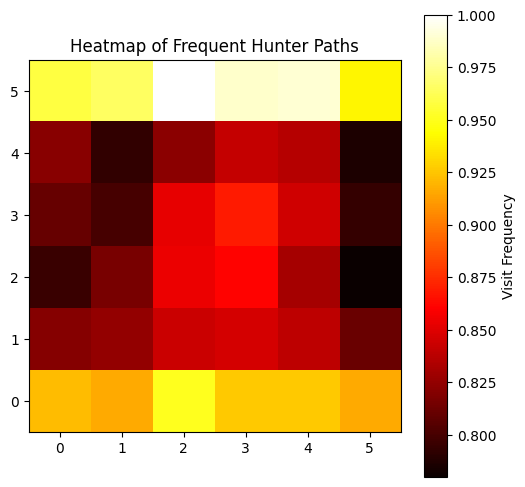

epsilons: [0.05003662286632564, 0.05003662286632564]
47
[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 99]


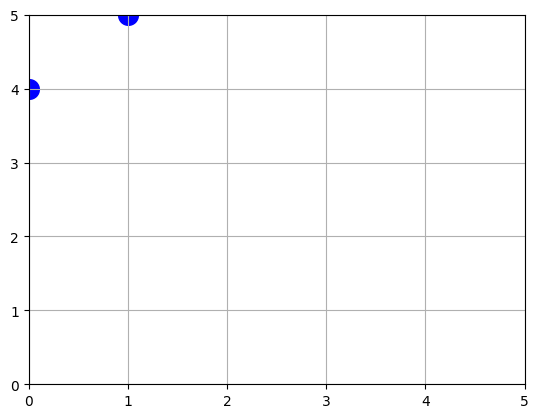

In [38]:
test_game(6, 100, 2, 5000, 5000, True, False, 1, False, 0.99, -1 ,load_existing=False)

### prey random move policy

training finished!

Agent 0 Q-table
Total states stored: 81
(0, 0, 0, 1, 3) -> [ 62.00767348  79.64641048  71.26760152  59.69758607 100.37836187]
(0, 0, 0, 1, 1) -> [ 67.03652102  80.40703469 101.10523331  83.53613283  81.19645344]
(1, 0, 0, 1, 1) -> [87.88272592 30.42845911 46.19978149 54.9715254  28.74756714]
(1, 0, 1, 0, 2) -> [82.2477463  38.06776697 33.79392331 49.08031625 27.64457346]
(1, 1, 1, 0, 2) -> [ 4.98607745  6.00741772 70.88198459 14.4054947  14.72114656]
(0, 0, 1, 0, 2) -> [ 55.7920062   56.72432799  26.00847598  75.00529482 100.87791479]
(1, 1, 0, 0, 2) -> [92.40598142 54.61118793 42.35894626 54.58785659 49.23850973]
(1, -1, 0, 0, 2) -> [42.6555927  79.89385194 34.9295237  47.78462146 27.26844497]
(0, 0, 1, 1, 0) -> [ 75.06081225  63.75338363  62.93481528 113.4585792   75.15584286]
(1, 0, 1, 1, 0) -> [15.55925694  8.19060124 74.97744797 19.83652465 18.1835006 ]
(0, 0, 0, 0, 1) -> [ 76.63703946  71.74170635  62.97541842  52.19795077 106.52031248]
(1, 1, 0, 0, 1) -> [28.

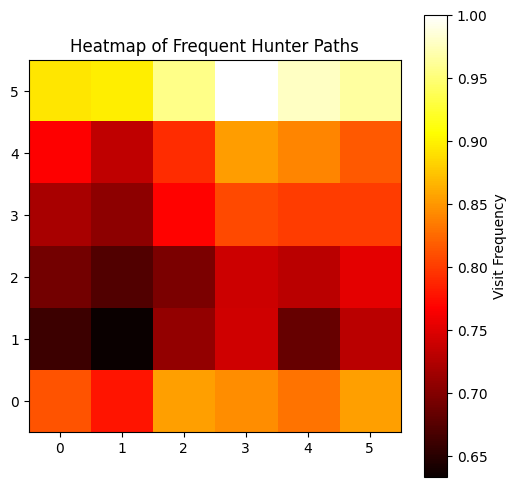

epsilons: [0.05003662286632564, 0.05003662286632564]
6
[-1, -1, -1, -1, -1, 99]


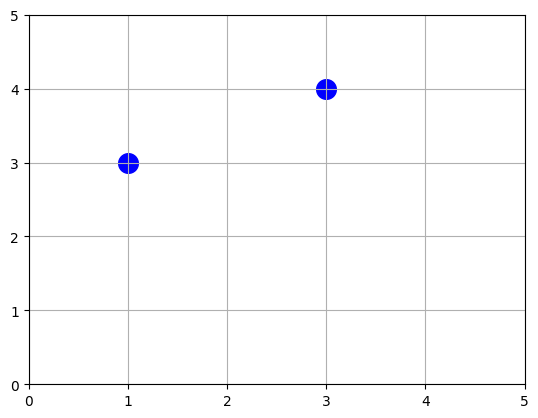

In [44]:
test_game(6, 100, 2, 5000, 5000, True, True, 1, False, 0.99, -1 ,load_existing=False)

### Escape prey move:

training finished!

Agent 0 Q-table
Total states stored: 81
(0, -1, 1, 0, 2) -> [17.2062969  24.46384974 48.63406299 15.98064736 24.23000141]
(0, 0, 1, 0, 2) -> [54.3618869  27.46152995 27.2412954  43.83503377 36.58380251]
(1, -1, 0, 0, 2) -> [16.75202666 24.87426557 32.7497675  16.40165773 19.20917735]
(1, 0, 0, 0, 2) -> [22.87585768 22.06953611 22.59826048 35.63092298 23.42570854]
(0, 1, 1, 1, 0) -> [30.01334139  5.71275623 13.36602741  6.22766612 -0.5160814 ]
(1, 1, 0, 0, 0) -> [22.04305457 21.24186918 21.34904283 32.98156325 22.22463554]
(1, 1, 0, 0, 2) -> [29.759914   19.54152641 19.69804406 23.72908668 22.24073258]
(-1, 1, 0, 0, 3) -> [29.84224269 11.49716482 10.83681314 11.06101713 14.22338345]
(0, 1, 0, 0, 3) -> [17.78791684 15.3367706  30.44742317 17.26564378 18.68323934]
(0, 0, 0, 0, 3) -> [47.08872876 33.32390031 27.06519945 27.70810699 36.15458623]
(0, 1, 0, 0, 2) -> [29.71407842 24.08338556 26.68332403 21.81459708 23.17071153]
(0, -1, 0, 0, 2) -> [13.25307917 20.11342907 4

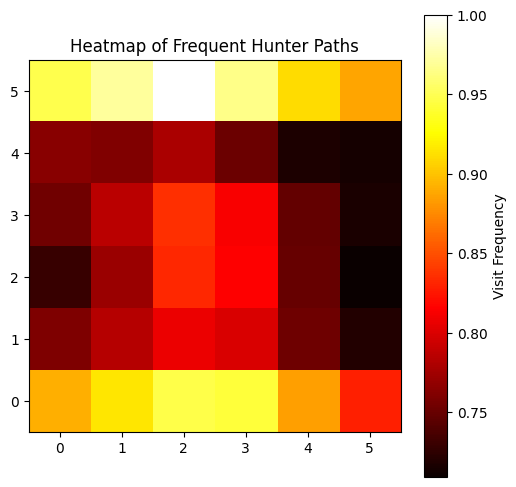

epsilons: [0.05003662286632564, 0.05003662286632564]
10
[-1, -1, -1, -1, -1, -1, -1, -1, -1, 99]


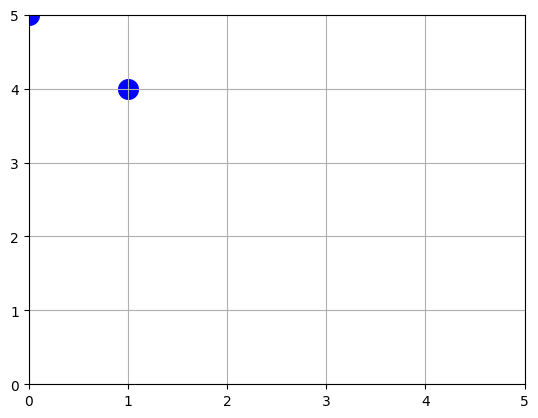

In [45]:
test_game(6, 100, 2, 5000, 5000, True, False, 1, False, 0.99, -1 ,load_existing=False)

### Hard grid:

training finished!

Agent 0 Q-table
Total states stored: 215
(0, 0, 0, 0, 3) -> [66.24144009  5.10093959 13.0727759  30.89277288  7.93802657]
(0, -1, 0, 0, 0) -> [ 3.13821878  8.89717604 93.11201289 16.7261019  12.79902236]
(0, -1, 1, 0, 0) -> [ 18.81268507   8.33039826 117.1736962    0.2442887   20.22740907]
(0, -2, 1, 0, 2) -> [32.28559619 21.53027422 83.9342333  33.09213153  9.50585514]
(0, -2, 1, 1, 0) -> [-0.07800953 -0.17286053 -0.3439     60.55143813  7.51028858]
(0, -2, 1, 0, 0) -> [37.07696818 -0.1        -0.1        -0.1        -0.1288593 ]
(0, -2, 0, 0, 1) -> [66.02343595 -0.63518159  6.56216945  6.52031965 -0.54719489]
(0, -2, 0, 0, 0) -> [ 4.82349785 21.32130797  0.         -0.19        0.        ]
(0, -2, 0, 1, 1) -> [68.95153096 -0.37639     7.34473529  1.93149027 13.046197  ]
(0, -2, 0, 1, 3) -> [ 0.40500666 -0.1        32.32138811 -0.1981      1.13796542]
(1, -2, 0, 1, 3) -> [-0.21424209 -0.35119     4.79644072 16.1673513  -0.199     ]
(1, -2, 0, 0, 2) -> [ 4.30342534 

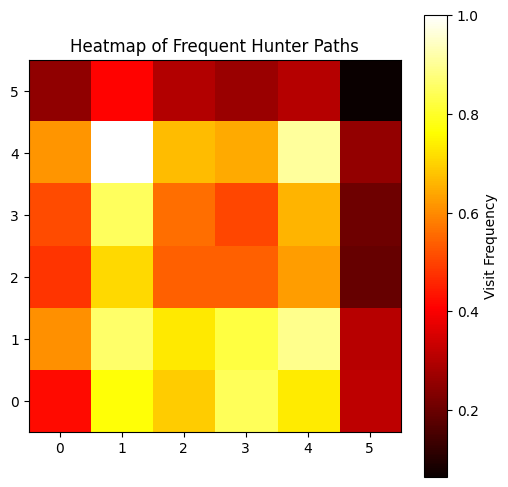

epsilons: [0.05003662286632564, 0.05003662286632564]
12
[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 99]


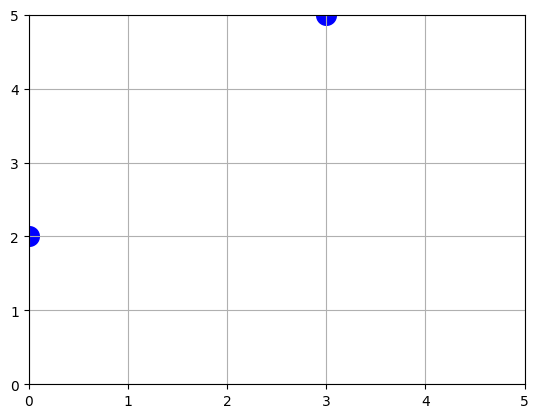

In [52]:
test_game(6, 100, 2, 5000, 5000, True, False, 1, False, 0.99, -1 ,load_existing=False)

### static epsilon (0.5):

training finished!
converged episode:  1006

Agent 0 Q-table
Total states stored: 215
(0, 0, 0, 0, 1) -> [125.21763875 121.42146065 123.56289411 130.97556672 120.85899805]
(0, 1, 0, 0, 1) -> [111.1647602  105.36387014  93.14263831  97.32679094 102.93394025]
(-1, 1, 0, 0, 1) -> [ 99.45334442 100.83296047  96.96024157  92.53535613  95.857333  ]
(-1, 0, 0, 0, 1) -> [122.69462523 124.95445047 105.82667097 112.70337359 109.12352671]
(-1, 0, 0, 1, 1) -> [119.78042823 117.12135301 107.30633892 110.80692103 110.26265712]
(-1, 1, 0, 1, 1) -> [102.78118991 107.05745593  85.14073651  77.74903184  90.56393088]
(0, 1, 0, 1, 1) -> [107.10509397  99.50674286  97.70409857 105.79616308 104.66417123]
(0, -1, 0, 1, 1) -> [ 93.696595   106.73801198 133.20829173 101.50692317 105.94035406]
(0, 0, 1, 0, 0) -> [125.60607326 124.05670863 131.54385805 133.00444351 123.4139799 ]
(1, 0, 1, 0, 0) -> [ 97.87209792  98.90886613  99.80747873 114.331994   100.05421996]
(1, 0, 0, 0, 0) -> [106.10525026 101.37888688 104

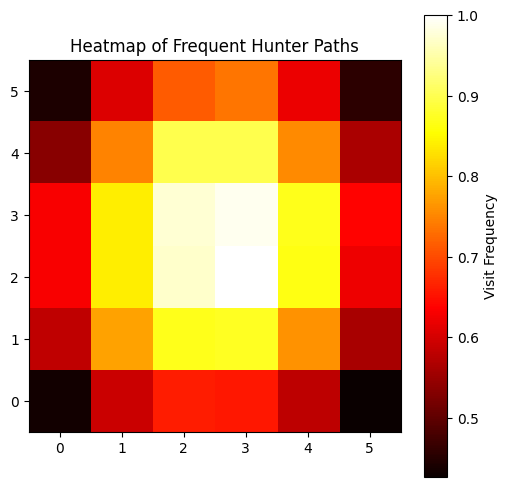

epsilons: [0.8, 0.8]
17
[-2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, 98]


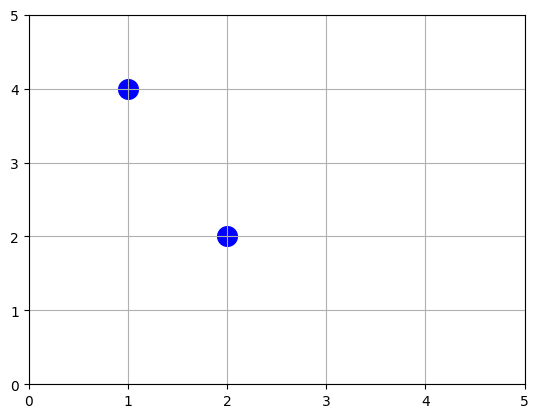

In [27]:
test_game(6, 100, 2, 5000, 5000, True, True, 1, False, 0.99, -2, 0.8, False, load_existing=False)

### first epsilon is 1 and it decays:

training finished!
converged episode:  1013

Agent 0 Q-table
Total states stored: 213
(-1, 0, 0, 0, 2) -> [ 97.72857061 120.85462071  90.872587    90.66724208  95.96372216]
(0, 0, 0, 0, 2) -> [127.41899929 109.53750185 111.29970691 112.65136108 138.23384504]
(-1, 0, 0, 0, 3) -> [ 9.38756069 98.41430079 -0.287965    7.46533981 11.80895822]
(0, 0, 0, 0, 0) -> [112.66205117 112.7074072  113.26124344 112.40946963 130.73114117]
(-1, 0, 1, 0, 0) -> [  7.60578293  42.86110397 104.26530551  37.23538781  56.36467067]
(0, 1, 1, 0, 0) -> [114.78781579  83.24975866  74.06885686  81.984435    73.89035645]
(-1, 1, 1, 0, 0) -> [ 10.92342026  30.57756838  28.24528446  12.21063992 107.89388802]
(-1, 1, 0, 0, 0) -> [ 57.4218093  107.6314773   37.50452506  76.7798008   56.32259291]
(0, 2, 1, 0, 0) -> [104.81179454   4.66051372  15.4290516    0.81630481  10.04367305]
(0, 0, 1, 0, 0) -> [111.54313326 111.13913924 111.50032964 136.33423441 111.17024344]
(0, 1, 0, 0, 0) -> [133.33026333 107.84312879 104.5137

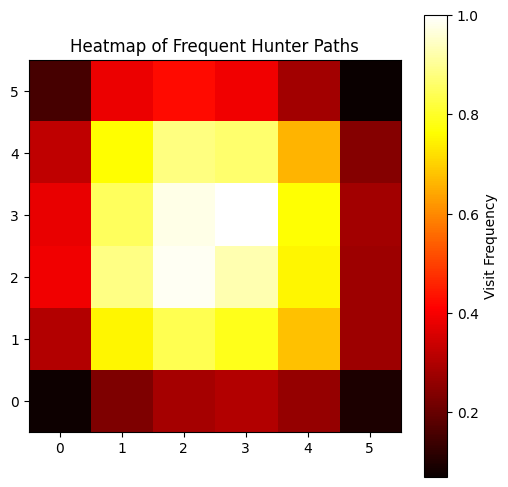

epsilons: [0.0500117151124688, 0.0500117151124688]
13
[-2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, 98]


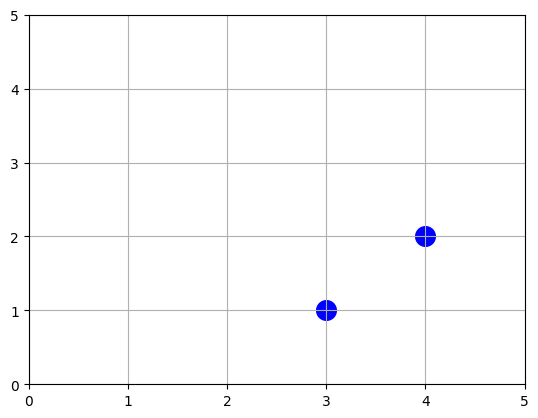

In [28]:
test_game(6, 100, 2, 5000, 5000, True, True, 1, False, 0.999, -2, 1, True, load_existing=False)

## random prey move

In [1]:
# import statistics
# agents = [Agent(6) for _ in range(2)]
# for episode in range(5000):
#     env = GridWorld(6, 300, agents, True, True, 2)
#     state = env.reset()
#     done = False
#     while not done:
#       reward, done = env.step()
#     for agent in agents:
#         agent.dec_epsilon(0.99)
# steps = []
# print("training finished!")
# rewards = []
# for episode in range(5000):
#     step = 0
#     env = GridWorld(6, 300, agents, True, True, 2)
#     state = env.reset()
#     done = False
#     reward_in_game = []
#     while not done:
#         step += 1
#         reward, done = env.step()
#         reward_in_game.append(reward)
#     rewards.append(sum(reward_in_game))
#     steps.append(step)
# steps_avg = statistics.mean(steps)
# rewards_avg = statistics.mean(rewards)
# # print(agent1.epsilon, agent2.epsilon)
# print("average steps: ",steps_avg)
# print("average rewards: ",rewards_avg)
# print("testing finished!")

In [2]:
# frames = []
# rewards = []
# done = False

# env = GridWorld(6, 300, agents, True, False, 2)
# print("epsilons:", [agent.epsilon for agent in agents])
# counter = 0
# while not done:
#     counter += 1
#     reward, done = env.step()
#     frames.append(
#         (
#             # np.array([agent.position.copy() for agent in env.agents]),
#             # np.array([prey.copy() for prey in env.preys])
#         [agent.position.copy() for agent in env.agents],
#         [prey.copy() for prey in env.preys]
#         )
#     )
#     rewards.append(reward)
# print(counter)
# print(rewards)

# import matplotlib.pyplot as plt
# from matplotlib import animation
# from IPython.display import HTML
# import numpy as np

# fig, ax = plt.subplots()
# ax.set_xlim(0, 5)
# ax.set_ylim(0, 5)
# ax.set_xticks(range(6))
# ax.set_yticks(range(6))
# ax.grid(True)

# hunter_scatter = ax.scatter([], [], c='blue', s=200, label='Hunters')
# prey_scatter = ax.scatter([], [], c='red', s=200, label='Preys')

# def init():
#     hunter_scatter.set_offsets(np.empty((0, 2)))
#     prey_scatter.set_offsets(np.empty((0, 2)))
#     return hunter_scatter, prey_scatter

# def update(frame):
#     hunters, preys = frame

#     hunters = np.asarray(hunters).reshape(-1, 2)

#     preys = np.asarray(preys)
#     if preys.size == 0:
#         preys = np.empty((0, 2))
#     else:
#         preys = preys.reshape(-1, 2)

#     hunter_scatter.set_offsets(hunters)
#     prey_scatter.set_offsets(preys)

#     return hunter_scatter, prey_scatter

# anim = animation.FuncAnimation(
#     fig,
#     update,
#     frames=frames,
#     init_func=init,
#     interval=300,
#     blit=True
# )

# HTML(anim.to_jshtml())


In [3]:
# import statistics
# agents = [Agent(6) for _ in range(2)]
# for episode in range(5000):
#     env = GridWorld(6, 300, agents, True, True)
#     state = env.reset()
#     done = False
#     while not done:
#       reward, done = env.step()
#     for agent in agents:
#         agent.dec_epsilon(0.99)
# steps = []
# print("training finished!")
# rewards = []
# for episode in range(5000):
#     step = 0
#     env = GridWorld(6, 300, agents, True, True)
#     state = env.reset()
#     done = False
#     reward_in_game = []
#     while not done:
#         step += 1
#         reward, done = env.step()
#         reward_in_game.append(reward)
#     rewards.append(sum(reward_in_game))
#     steps.append(step)
# steps_avg = statistics.mean(steps)
# rewards_avg = statistics.mean(rewards)
# # print(agent1.epsilon, agent2.epsilon)
# print("average steps: ",steps_avg)
# print("average rewards: ",rewards_avg)
# print("testing finished!")

In [4]:
# frames = []
# rewards = []
# done = False

# env = GridWorld(6, 300, agents, True, True)
# print("epsilons:", [agent.epsilon for agent in agents])
# counter = 0
# while not done:
#     counter += 1
#     reward, done = env.step()
#     frames.append(
#         (
#             np.array([agent.position.copy() for agent in env.agents]),
#             env.prey.copy()
#         )
#     )
#     rewards.append(reward)
# print(counter)
# print(rewards)

# import matplotlib.pyplot as plt
# from matplotlib import animation
# from IPython.display import HTML
# import numpy as np

# fig, ax = plt.subplots()
# ax.set_xlim(0, 5)
# ax.set_ylim(0, 5)
# ax.set_xticks(range(6))
# ax.set_yticks(range(6))
# ax.grid(True)

# hunter_scatter = ax.scatter([], [], c='blue', s=200, label='Hunters')
# prey_scatter = ax.scatter([], [], c='red', s=200, label='Prey')
# ax.legend(loc='upper right')

# def init():
#     hunter_scatter.set_offsets(np.empty((0, 2)))
#     prey_scatter.set_offsets(np.empty((0, 2)))
#     return hunter_scatter, prey_scatter

# def update(frame):
#     hunters, prey = frame

#     hunters = np.array(hunters)   # ← این خط کلیدی است
#     prey = np.array(prey)

#     hunter_scatter.set_offsets(hunters)
#     prey_scatter.set_offsets([prey])

#     return hunter_scatter, prey_scatter

# anim = animation.FuncAnimation(
#     fig,
#     update,
#     frames=frames,
#     init_func=init,
#     interval=300,
#     blit=True
# )

# HTML(anim.to_jshtml())


## test function

### 2 prey random move

### 2 prey greedy move

## saman

In [ ]:
# import numpy as np
# import random
# from collections import defaultdict

# class Agent:
#     def __init__(self, size):
#         self.size = size
#         self.Q = defaultdict(lambda: np.zeros(5))
#         self.epsilon = 0.5
#         self.alpha = 0.1
#         self.gamma = 0.9
#         self.position = [random.randint(0, self.size-1), random.randint(0, self.size-1)]
#         self.greedy_baseline = False

#     def dec_epsilon(self, x):
#         if self.epsilon * x >= 0.05:
#           self.epsilon = self.epsilon * x

#     def choose_action(self, state):
#         # index = state_to_index(state)
#         if self.greedy_baseline == False:
#             if np.random.rand() < self.epsilon:
#                 return np.random.randint(0, 5)
#             else:
#                 return np.argmax(self.Q[state])
#         else:
#             dx, dy, _, _, _ = state

#             if dx > 0:
#                 return 3  # LEFT
#             elif dx < 0:
#                 return 1  # RIGHT
#             elif dy > 0:
#                 return 0  # UP
#             elif dy < 0:
#                 return 2  # DOWN
#             else:
#                 return 4  # STAY if already on prey

#     def update(self, state, action, reward, next_state):
#         # index = state_to_index(state)
#         # next_index = state_to_index(next_state)
#         if self.greedy_baseline:
#             return  # skip update
#         self.Q[state][action] += self.alpha * (
#             reward + self.gamma * np.max(self.Q[next_state]) - self.Q[state][action]
#         )
# from enum import Enum

# class RewardScenario(Enum):
#     COOPERATIVE = "Cooperative"
#     SELFISH = "Selfish"

# class WallType(Enum):
#     TORUS = "Torus"
#     HARD = "Hard"
# class GridWorld:
#     def __init__(self, size, max_steps, agents, is_local):
#         self.size = size
#         self.max_steps = max_steps
#         self.num_agents = len(agents)
#         self.agents = agents
#         self.reset()
#         self.is_local = is_local
#         self.rewardSenario = RewardScenario.COOPERATIVE #Selfish
#         self.WINNING_REWARD = 100
#         self.walls = WallType.TORUS #Hard


#     def reset(self):
#         self.preys = [
#         np.array([random.randint(0, self.size-1),
#                 random.randint(0, self.size-1)])
#                 for _ in range(2)]
#         self.steps = 0
#         self.done = False
#         return None

#     def get_local_state(self, agent_idx):
#         agent1 = self.agents[agent_idx]
#         others = [a for i, a in enumerate(self.agents) if i != agent_idx]
#         agent2 = min(
#         others,
#         key=lambda a: abs(a.position[0]-agent1.position[0]) +
#                       abs(a.position[1]-agent1.position[1])
#         ) 
#         # Find the closest prey
#         closest_prey = None
#         closest_distance = float('inf')

#         for prey in self.preys:
#             if self.walls == WallType.TORUS:
#                 dx = abs(prey[0] - agent1.position[0])
#                 dy = abs(prey[1] - agent1.position[1])
#                 dx = min(dx, self.size - dx)
#                 dy = min(dy, self.size - dy)
#                 distance = dx + dy
#             else:
#                 distance = abs(prey[0] - agent1.position[0]) + abs(prey[1] - agent1.position[1])
                
#             if distance < closest_distance:
#                 closest_distance = distance
#                 closest_prey = prey

#         # Calculate the differences
#         if not self.preys:
#             dx = 0
#             dy = 0
#         else:
#             if self.walls == WallType.TORUS:
#                 dx = (agent1.position[0] - closest_prey[0]) % self.size
#                 if dx > self.size // 2:
#                     dx -= self.size
#                 dy = (agent1.position[1] - closest_prey[1]) % self.size
#                 if dy > self.size // 2:
#                     dy -= self.size
#             else:
#                 dx = agent1.position[0] - closest_prey[0]
#                 dy = agent1.position[1] - closest_prey[1]

#         if(dx == 0):
#             x_direction = 0
#         else:
#             x_direction = dx // abs(dx)
#         if(dy == 0):
#             y_direction = 0
#         else:
#             y_direction = dy // abs(dy) 

#         if(abs(dx) < 2):
#             dx = 0
#         elif(abs(dx) < 4):
#             dx = 1 * x_direction
#         else:
#             dx = 2 * x_direction

#         if(abs(dy) < 2):
#             dy = 0
#         elif(abs(dy) < 4):
#             dy = 1 * y_direction
#         else:
#             dy = 2 * y_direction
        
#         agents_x_diff = agent1.position[0] - agent2.position[0]
#         agents_y_diff = agent1.position[1] - agent2.position[1]
#         same_row = int(agents_x_diff == 0)
#         same_col = int(agents_y_diff == 0)
#         direction = None
#         if(abs(agents_x_diff) > abs(agents_y_diff)):
#             if agents_x_diff > 0:
#                 direction = 1
#             else:
#                 direction = 3
#         else:
#             if agents_y_diff > 0:
#                 direction = 0
#             else:
#                 direction = 2

#         return(dx, dy, same_row, same_col, direction)

#     def get_state(self, agent_idx): 
#         if (self.is_local):
#             return self.get_local_state(agent_idx)
#         else:
#             state = []
#             for agent in self.agents:
#                 state.extend(agent.position)
#             for prey in self.preys:
#                 state.extend(prey)
#             return tuple(state)



#     def move(self, pos, action):
#         x, y = pos
#         nx, ny = x, y   # proposed next position

#         if action == 0:      # UP
#             ny -= 1
#         elif action == 1:    # RIGHT
#             nx += 1
#         elif action == 2:    # DOWN
#             ny += 1
#         elif action == 3:    # LEFT
#             nx -= 1
#         elif action == 4:    # STAY
#             pass

#         if self.walls == WallType.TORUS:
#             nx %= self.size
#             ny %= self.size
#         else:  # Hard walls
#             if not (0 <= nx < self.size and 0 <= ny < self.size):
#                 nx, ny = x, y  # cancel move

#         return [nx, ny]

#     def step(self):
#         if self.done:
#             return  0, True

#         self.steps += 1
#         reward = -1  # negative reward per step

#         states = []
#         actions = []
#         for i, agent in enumerate(self.agents):
#             state = self.get_state(i)
#             action = agent.choose_action(state)
#             agent.position = self.move(agent.position, action)
#             states.append(state)
#             actions.append(action)
#         for i in range(len(self.preys)):
#             prey_action = random.randint(0, 4)
#             self.preys[i] = self.move(self.preys[i], prey_action)

#         winners = set()
#         captured_preys = []

#         for i, agent in enumerate(self.agents):
#             for prey in self.preys:
#                 if np.array_equal(agent.position, prey):
#                     winners.add(i)
#                     captured_preys.append(prey)

#         self.preys = [
#             prey for prey in self.preys
#             if not any(np.array_equal(prey, cp) for cp in captured_preys)
#         ]

#         if len(self.preys) == 0:
#             self.done = True
                    


#         if self.done:
#             if self.rewardSenario == RewardScenario.COOPERATIVE:
#                 reward += len(captured_preys) * self.WINNING_REWARD
#                 for j in range(len(self.agents)):
#                     next_state = self.get_state(j) 
#                     self.agents[j].update(states[j], actions[j], reward, next_state)
#             elif self.rewardSenario == RewardScenario.SELFISH:
#                 for j in range(len(self.agents)):
#                     next_state = self.get_state(j) 
#                     if j in winners:
#                         count = sum(
#                             1 for prey in captured_preys
#                             if np.array_equal(self.agents[j].position, prey)
#                         )                     
#                         self.agents[j].update(states[j], actions[j], reward + count * self.WINNING_REWARD, next_state)                    
#                     else:
#                         self.agents[j].update(states[j], actions[j], reward, next_state) 
#         else:
#             for j in range(len(self.agents)):
#                 next_state = self.get_state(j) 
#                 self.agents[j].update(states[j], actions[j], reward, next_state)




#         if self.steps >= self.max_steps:
#             self.done = True

#         return  reward, self.done



